# Fine-tuning YAMNet on ESC-50

Transfer learning pipeline that adapts Google's YAMNet audio classifier to the
[ESC-50](https://github.com/karolpiczak/ESC-50) dataset (2,000 clips, 50 environmental sound classes),
then exports a TensorFlow Lite model for on-device inference in an Android app.

**Approach:** YAMNet is used as a frozen feature extractor. Each audio clip is converted into
1024-dimensional embeddings, and a small dense classifier is trained on top. This is far faster
than training from scratch and works well with a few thousand samples.

**Runtime:** Set to GPU via *Runtime → Change runtime type → T4 GPU* (optional but faster).

## 1. Setup

In [1]:
!pip install -q tensorflow tensorflow_hub tensorflow_io

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print('TensorFlow', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 116.9 MB/s eta 0:00:00
TensorFlow 2.20.0
GPU available: True


## 2. Download ESC-50

2,000 five-second clips, 40 per class, sampled at 44.1 kHz.

In [3]:
!wget -q https://github.com/karoldvl/ESC-50/archive/master.zip -O esc50.zip
!unzip -q esc50.zip
!rm esc50.zip

ESC50_DIR = 'ESC-50-master'
AUDIO_DIR = os.path.join(ESC50_DIR, 'audio')
meta = pd.read_csv(os.path.join(ESC50_DIR, 'meta', 'esc50.csv'))

print(f'{len(meta)} clips, {meta.category.nunique()} classes')
meta.head()

2000 clips, 50 classes


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


## 3. Load YAMNet

YAMNet expects **16 kHz mono float32** audio in the range −1…1. ESC-50 is 44.1 kHz,
so every clip must be resampled — the same conversion the Android app performs at runtime.

In [4]:
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
TARGET_SR = 16000

# Sanity check: YAMNet returns (scores, embeddings, spectrogram)
test_wav = np.zeros(TARGET_SR, dtype=np.float32)
scores, embeddings, spectrogram = yamnet_model(test_wav)
print('scores    ', scores.shape)      # (frames, 521)
print('embeddings', embeddings.shape)  # (frames, 1024)

scores     (2, 521)
embeddings (2, 1024)


## 4. Data preparation

Decode each WAV, convert to mono, resample to 16 kHz, and normalize.

In [5]:
import soundfile as sf
from scipy.signal import resample_poly
from math import gcd

def load_wav_16k_mono(path):
    """Read a WAV file and return a 16 kHz mono float32 numpy array."""
    wav, sr = sf.read(path, dtype='float32')
    if wav.ndim > 1:                       # stereo -> mono
        wav = wav.mean(axis=1)
    if sr != TARGET_SR:                    # resample to 16 kHz
        g = gcd(sr, TARGET_SR)
        wav = resample_poly(wav, TARGET_SR // g, sr // g)
    return wav.astype(np.float32)

# Build label mapping
classes = sorted(meta.category.unique())
class_to_id = {c: i for i, c in enumerate(classes)}
meta['label'] = meta.category.map(class_to_id)

print(f'{len(classes)} classes')
print(classes[:10], '...')

50 classes
['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping'] ...


### Train / validation / test split

ESC-50 ships with five predefined folds. Using them (rather than a random split) prevents
clips from the same source recording appearing in both training and test sets.

In [6]:
meta['path'] = meta.filename.apply(lambda f: os.path.join(AUDIO_DIR, f))

# Train on folds 1-4 (80% of the data), hold out fold 5 for testing.
# A slice of the training folds is carved off for validation, so no data is wasted.
trainval_df = meta[meta.fold.isin([1, 2, 3, 4])].sample(frac=1, random_state=42)
split = int(len(trainval_df) * 0.9)

train_df = trainval_df.iloc[:split]
val_df   = trainval_df.iloc[split:]
test_df  = meta[meta.fold == 5]

print(f'train {len(train_df)}  val {len(val_df)}  test {len(test_df)}')

train 1440  val 160  test 400


## 5. Extract YAMNet embeddings

YAMNet slices audio into ~0.96 s frames and emits one 1024-d embedding per frame.
Each 5-second clip therefore produces several embeddings, all sharing the clip's label —
which conveniently multiplies the effective size of the training set.

###Cell A — augmentation functions

In [7]:
# --- Audio augmentation ---------------------------------------------------
# Applied to training clips only. Validation and test sets stay clean so the
# reported accuracy reflects real-world performance.

rng = np.random.default_rng(42)

def aug_time_shift(wav, max_frac=0.3):
    """Roll the waveform circularly by a random offset."""
    shift = rng.integers(-int(len(wav) * max_frac), int(len(wav) * max_frac))
    return np.roll(wav, shift)

def aug_add_noise(wav, snr_db_range=(10, 30)):
    """Mix in white noise at a random signal-to-noise ratio."""
    snr_db = rng.uniform(*snr_db_range)
    sig_power = np.mean(wav ** 2) + 1e-10
    noise_power = sig_power / (10 ** (snr_db / 10))
    noise = rng.normal(0, np.sqrt(noise_power), len(wav))
    return (wav + noise).astype(np.float32)

def aug_gain(wav, db_range=(-6, 6)):
    """Random volume change."""
    gain = 10 ** (rng.uniform(*db_range) / 20)
    return np.clip(wav * gain, -1.0, 1.0).astype(np.float32)

def aug_time_stretch(wav, rate_range=(0.85, 1.15)):
    """Speed up or slow down (also shifts pitch — cheap but effective)."""
    rate = rng.uniform(*rate_range)
    n_out = int(len(wav) / rate)
    idx = np.linspace(0, len(wav) - 1, n_out)
    return np.interp(idx, np.arange(len(wav)), wav).astype(np.float32)

def augment(wav):
    """Apply a random combination of augmentations."""
    out = wav.copy()
    if rng.random() < 0.5:
        out = aug_time_shift(out)
    if rng.random() < 0.5:
        out = aug_add_noise(out)
    if rng.random() < 0.5:
        out = aug_gain(out)
    if rng.random() < 0.3:
        out = aug_time_stretch(out)
    return out

print('Augmentation ready')

Augmentation ready


###Cell B — augmented extraction

In [8]:
def extract_embeddings_aug(df, n_aug=0, desc=''):
    """Extract YAMNet embeddings. n_aug extra augmented copies per clip."""
    X, y = [], []
    total = len(df)
    for i, (path, label) in enumerate(zip(df.path.values, df.label.values)):
        wav = load_wav_16k_mono(path)

        versions = [wav] + [augment(wav) for _ in range(n_aug)]
        for v in versions:
            _, emb, _ = yamnet_model(v)
            e = emb.numpy()
            X.append(e)
            y.append(np.full(e.shape[0], label))

        if (i + 1) % 200 == 0:
            print(f'  {desc} {i + 1}/{total}')
    return np.concatenate(X), np.concatenate(y)


print('Extracting embeddings with augmentation (this takes longer)...')
X_train, y_train = extract_embeddings_aug(train_df, n_aug=4, desc='train')
X_val,   y_val   = extract_embeddings_aug(val_df,   n_aug=0, desc='val')
X_test,  y_test  = extract_embeddings_aug(test_df,  n_aug=0, desc='test')

print('train', X_train.shape, 'val', X_val.shape, 'test', X_test.shape)

Extracting embeddings with augmentation (this takes longer)...
  train 200/1440
  train 400/1440
  train 600/1440
  train 800/1440
  train 1000/1440
  train 1200/1440
  train 1400/1440
  test 200/400
  test 400/400
train (72054, 1024) val (1600, 1024) test (4000, 1024)


In [9]:
#def extract_embeddings(df, desc=''):
    #X, y = [], []
    #total = len(df)
    #for i, (path, label) in enumerate(zip(df.path.values, df.label.values)):
       # wav = load_wav_16k_mono(path)
        #_, embeddings, _ = yamnet_model(wav)
        #emb = embeddings.numpy()
        #X.append(emb)
        #y.append(np.full(emb.shape[0], label))
        #if (i + 1) % 200 == 0:
            #print(f'  {desc} {i + 1}/{total}')
    #return np.concatenate(X), np.concatenate(y)

#print('Extracting embeddings (a few minutes)...')
#X_train, y_train = extract_embeddings(train_df, 'train')
#X_val,   y_val   = extract_embeddings(val_df,   'val')
#X_test,  y_test  = extract_embeddings(test_df,  'test')

#print('train', X_train.shape, 'val', X_val.shape, 'test', X_test.shape)

###Cell 1 — Windowing function

In [10]:
# --- Temporal context windowing -------------------------------------------
# Stack CONTEXT consecutive embeddings so each prediction sees its neighbours.
# A quiet frame between dog barks becomes classifiable in context.

CONTEXT = 3          # frames per window (must be odd for a centred window)
HALF = CONTEXT // 2

def make_windows(emb):
    """(frames, 1024) -> (frames, CONTEXT*1024) with edge padding."""
    padded = np.pad(emb, ((HALF, HALF), (0, 0)), mode='edge')
    return np.stack(
        [padded[i:i + CONTEXT].reshape(-1) for i in range(emb.shape[0])]
    )

def extract_windowed(df, n_aug=0, desc=''):
    """Extract YAMNet embeddings and apply temporal windowing per clip."""
    X, y = [], []
    total = len(df)
    for i, (path, label) in enumerate(zip(df.path.values, df.label.values)):
        wav = load_wav_16k_mono(path)
        versions = [wav] + [augment(wav) for _ in range(n_aug)]
        for v in versions:
            _, emb, _ = yamnet_model(v)
            w = make_windows(emb.numpy())      # windows must be per-clip
            X.append(w)
            y.append(np.full(w.shape[0], label))
        if (i + 1) % 200 == 0:
            print(f'  {desc} {i + 1}/{total}')
    return np.concatenate(X), np.concatenate(y)

print(f'Windowing ready: {CONTEXT} frames -> {CONTEXT * 1024} features')

Windowing ready: 3 frames -> 3072 features


###Cell 2 — Re-extract with windowing

In [11]:
print('Extracting windowed embeddings...')
X_train, y_train = extract_windowed(train_df, n_aug=4, desc='train')
X_val,   y_val   = extract_windowed(val_df,   n_aug=0, desc='val')
X_test,  y_test  = extract_windowed(test_df,  n_aug=0, desc='test')

print('train', X_train.shape, 'val', X_val.shape, 'test', X_test.shape)

Extracting windowed embeddings...
  train 200/1440
  train 400/1440
  train 600/1440
  train 800/1440
  train 1000/1440
  train 1200/1440
  train 1400/1440
  test 200/400
  test 400/400
train (72012, 3072) val (1600, 3072) test (4000, 3072)


###Cell 3 — Model with wider input

In [12]:
NUM_CLASSES = len(classes)
INPUT_DIM = CONTEXT * 1024

classifier = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(INPUT_DIM,), dtype=tf.float32, name='embedding'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(1024, activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(512, activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(256, activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
], name='esc50_classifier_context')

y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy'],
)
classifier.summary()

Model: "esc50_classifier_context"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 3072)           │        12,288 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,835,186 (14.63 MB)

 Trainable params: 3,825,458 (14.59 MB)

 Non-trainable params: 9,728 (38.00 KB)

## 6. Train the classifier head

A small dense network over the frozen embeddings. Dropout guards against overfitting,
which matters because frames from the same clip are highly correlated.

In [13]:
NUM_CLASSES = len(classes)
INPUT_DIM = CONTEXT * 1024

classifier = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(INPUT_DIM,), dtype=tf.float32, name='embedding'),
    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(1024, activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(512, activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(256, activation=None),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax'),
], name='esc50_classifier_context')

# One-hot labels are required for label smoothing
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

classifier.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy'],
)
classifier.summary()

Model: "esc50_classifier_context"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_4           │ (None, 3072)           │        12,288 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,835,186 (14.63 MB)

 Trainable params: 3,825,458 (14.59 MB)

 Non-trainable params: 9,728 (38.00 KB)

In [14]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True,
                                     monitor='val_accuracy'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor='val_loss'),
]

history = classifier.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=60,
    batch_size=64,
    callbacks=callbacks,
)

Epoch 1/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.6121 - loss: 1.9951 - val_accuracy: 0.7531 - val_loss: 1.5267 - learning_rate: 0.0010
Epoch 2/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7286 - loss: 1.5889 - val_accuracy: 0.7563 - val_loss: 1.5003 - learning_rate: 0.0010
Epoch 3/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7610 - loss: 1.4810 - val_accuracy: 0.7638 - val_loss: 1.4782 - learning_rate: 0.0010
Epoch 4/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7833 - loss: 1.4063 - val_accuracy: 0.7663 - val_loss: 1.4515 - learning_rate: 0.0010
Epoch 5/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7994 - loss: 1.3547 - val_accuracy: 0.7638 - val_loss: 1.4756 - learning_rate: 0.0010
Epoch 6/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8125 - loss: 1.3176 - val_accuracy: 0.7656 - val_loss: 1.4582 - learning_rate: 0.0010
Epoch 7/60
1126/1126 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8231 - 

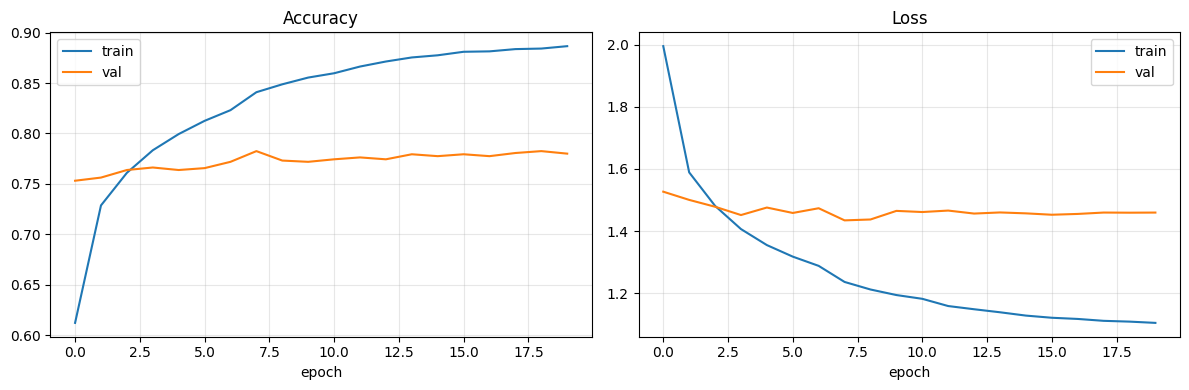

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy'); ax1.set_xlabel('epoch'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Loss'); ax2.set_xlabel('epoch'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Evaluate

Frame-level accuracy first, then clip-level accuracy — averaging predictions across a clip's
frames is what an application would actually do, and it scores noticeably higher.

In [16]:
frame_loss, frame_acc = classifier.evaluate(X_test, y_test_oh, verbose=0)
print(f'Frame-level test accuracy: {frame_acc:.3f}')

# Clip-level: average the softmax outputs over each clip's frames
clip_correct = 0
for path, label in zip(test_df.path.values, test_df.label.values):
    wav = load_wav_16k_mono(path)
    _, emb, _ = yamnet_model(wav)
    w = make_windows(emb.numpy())
    probs = classifier.predict(w, verbose=0).mean(axis=0)
    if np.argmax(probs) == label:
        clip_correct += 1

print(f'Clip-level test accuracy:  {clip_correct / len(test_df):.3f}')

Frame-level test accuracy: 0.731
Clip-level test accuracy:  0.880


In [17]:
y_pred = classifier.predict(X_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))

                  precision    recall  f1-score   support

        airplane       0.52      0.41      0.46        80
       breathing       0.69      0.62      0.66        80
  brushing_teeth       0.89      0.85      0.87        80
     can_opening       0.59      0.44      0.50        80
        car_horn       0.79      0.65      0.71        80
             cat       0.80      0.55      0.65        80
        chainsaw       0.95      0.91      0.93        80
  chirping_birds       0.79      0.72      0.76        80
    church_bells       1.00      0.97      0.99        80
        clapping       0.79      0.65      0.71        80
     clock_alarm       0.94      0.97      0.96        80
      clock_tick       0.91      0.75      0.82        80
        coughing       0.62      0.56      0.59        80
             cow       0.73      0.70      0.71        80
  crackling_fire       0.74      0.68      0.71        80
        crickets       0.73      0.90      0.80        80
            c

## 8. Combine YAMNet + classifier into one model

The Android app should receive raw waveform samples and get class scores back, without
having to run two models itself. Wrapping both into a single graph keeps the app simple.

In [19]:
class CombinedModel(tf.Module):
    def __init__(self, yamnet, classifier):
        super().__init__()
        self.yamnet = yamnet
        self.classifier = classifier

    @tf.function(input_signature=[tf.TensorSpec(shape=[None], dtype=tf.float32)])
    def __call__(self, waveform):
        _, embeddings, _ = self.yamnet(waveform)

        # Replicate the make_windows logic in pure TensorFlow (for CONTEXT=3, HALF=1)
        # Pad with edge values
        first = embeddings[:1, :]
        last = embeddings[-1:, :]
        padded = tf.concat([first, embeddings, last], axis=0)

        # Create sliding windows
        w0 = padded[:-2, :]
        w1 = padded[1:-1, :]
        w2 = padded[2:, :]

        # Concatenate horizontally to get (frames, 3072)
        windowed = tf.concat([w0, w1, w2], axis=1)

        probs = self.classifier(windowed)
        return {'scores': tf.reduce_mean(probs, axis=0)}

combined = CombinedModel(yamnet_model, classifier)
tf.saved_model.save(combined,'combined_saved_model')
print('Saved.')

Saved.


## 9. Convert to TensorFlow Lite

In [20]:
converter = tf.lite.TFLiteConverter.from_saved_model('combined_saved_model')
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,   # YAMNet uses some ops without TFLite equivalents
]
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('esc50_yamnet.tflite', 'wb') as f:
    f.write(tflite_model)

with open('esc50_labels.txt', 'w') as f:
    f.write('\n'.join(classes))

size_mb = len(tflite_model) / 1e6
print(f'esc50_yamnet.tflite  {size_mb:.1f} MB')
print(f'esc50_labels.txt     {len(classes)} labels')

esc50_yamnet.tflite  3.4 MB
esc50_labels.txt     50 labels


## 10. Verify the TFLite model

Always test the converted model before shipping it — quantization and op selection can
change behaviour relative to the Keras version.

In [21]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
runner = interpreter.get_signature_runner()

correct = 0
sample = test_df.sample(50, random_state=0)
for path, label in zip(sample.path.values, sample.label.values):
    wav = load_wav_16k_mono(path)
    out = runner(waveform=wav)
    pred = np.argmax(out['scores'])
    correct += int(pred == label)

print(f'TFLite accuracy on 50 test clips: {correct / 50:.2f}')

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


TFLite accuracy on 50 test clips: 0.02


## 11. Download

Place `esc50_yamnet.tflite` in the Android project at
`android/app/src/main/assets/` and update `MODEL_FILE` in `AudioClassifierModule.java`.

In [22]:
from google.colab import files
files.download('esc50_yamnet.tflite')
files.download('esc50_labels.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## Notes

- **Why freeze YAMNet.** With 2,000 clips, fine-tuning 3.7M parameters would overfit badly.
  Training only the head keeps the learned audio representation intact and converges in minutes.
- **Frames vs clips.** YAMNet emits one embedding per ~0.96 s frame, so each 5-second clip
  yields several training examples. At inference the frame predictions are averaged, which
  smooths out momentary confusion and raises accuracy.
- **Fold-based splitting.** ESC-50 clips are cut from longer source recordings; a random split
  would leak near-duplicate audio between train and test and inflate the score.
- **SELECT_TF_OPS.** YAMNet's preprocessing uses ops that have no TFLite builtin equivalent,
  so the Flex delegate is required. This increases model size and means the Android build
  needs the `tensorflow-lite-select-tf-ops` dependency.
- **Possible improvements.** Data augmentation (time shift, noise, pitch), per-class threshold
  tuning, and full fine-tuning of YAMNet's upper layers with a very low learning rate.